# K-Means

<center>
  <img src="https://miro.medium.com/max/1200/1*rw8IUza1dbffBhiA4i0GNQ.png"><br>
  image from: <a href="https://towardsdatascience.com/k-means-a-complete-introduction-1702af9cd8c">K-means: A Complete Introduction</a>
</center>

# Preparation

* ใช้ DataFrame จาก pandas จัดการข้อมูล
```
import pandas as pd
```

* (optional) ใช้ matplotlib.pyplot ในการวาดกราฟ
```
import matplotlib.pyplot as plt
```

* ใช้ KMeans จาก sklearn.cluster เพื่อทำ Clustering
```
from sklearn.cluster import KMeans
```

* ใช้ Elbow Method ในการหาจำนวนกลุ่ม
```
from yellowbrick.cluster import KElbowVisualizer
```

In [163]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# **Lab-1** Customer Segmentation

## สร้าง DataFrame เพื่อจัดการชุดข้อมูล

1.   สร้างชุดข้อมูลจากตัวอย่างในสไลด์
```
{
        'age': [42, 18, 23, 49, 37, 51, 40, 20],
        'eng': [7, 3, 2, 1, 7, 1, 6, 4]
}
```

In [164]:
data = {
   'age': [42, 18, 23, 49, 37, 51, 40, 20],
   'eng': [7, 3, 2, 1, 7, 1, 6, 4]
}
data

{'age': [42, 18, 23, 49, 37, 51, 40, 20], 'eng': [7, 3, 2, 1, 7, 1, 6, 4]}

2.   สร้าง DataFrame จากชุดข้อมูล
```
pd.DataFrame()
```

In [165]:
# สร้าง DataFrame ตั้งชื่่อว่า customer_df
customer_df = pd.DataFrame(data)
customer_df


,age,eng
0,42,7
1,18,3
2,23,2
3,49,1
4,37,7
5,51,1
6,40,6
7,20,4


## สร้างโมเดลของ k-means
```
KMeans(n_clusters=?)
```

In [166]:
# สร้างโมเดลของ k-means ตั้งชื่อว่า customer_kmeans, กำหนด random_state=345
customer_kmeans = KMeans(n_clusters=3,random_state=345)
customer_kmeans

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",345
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


## ให้ model เรียนรู้จากชุดข้อมูลใน DataFrame
```
fit()
```

In [167]:
customer_kmeans.fit(customer_df)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",345
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


## ดูผลการทำ Clustering

* Centroids
```
cluster_centers_
```

In [168]:
customer_kmeans.cluster_centers_

array([[20.33333333,  3.        ],
       [39.66666667,  6.66666667],
       [50.        ,  1.        ]])

* Labels
```
labels_
```

In [169]:
customer_kmeans.labels_

array([1, 0, 0, 2, 1, 2, 1, 0], dtype=int32)

## (optional) วาดกราฟ
```
plt.scatter()
```

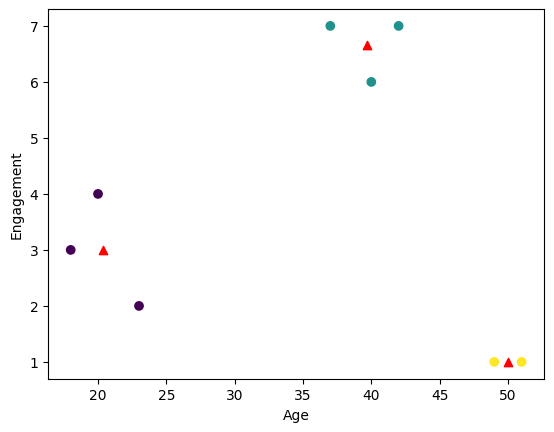

In [170]:
plt.scatter(y=customer_df['eng'], x=customer_df['age'], c=customer_kmeans.labels_)
plt.scatter(y=customer_kmeans.cluster_centers_[:,1],
            x=customer_kmeans.cluster_centers_[:,0], c='red', marker='^')
plt.xlabel('Age')
plt.ylabel('Engagement')
plt.show()

## Within Cluster Sum Of Square
```
inertia_
```

In [171]:
customer_kmeans.inertia_

30.0

# **Lab-2** - Grains Clustering

ใช้ข้อมูลของธัญญพืชที่ให้มานี้ แสดงวิธีการทำ Clustering โดยหาจำนวนกลุ่มที่เหมาะสมที่สุด พร้อมทั้งอธิบายลักษณะของแต่ละกลุ่มที่ได้
```
{
    'sugar': [6, 8, 5, 0, 8, 10, 14, 8, 6, 5, 12, 1, 9, 7, 13],
    'cal': [70, 120, 70, 50, 110, 110, 110, 130, 90, 90, 120, 110, 120, 110, 110],
    'protein': [4, 3,4, 4, 2, 2, 2, 3, 2, 3, 1, 6, 1, 3, 1],
    'fat': [1, 5, 1, 0, 2, 2, 0, 2, 1, 0, 2, 2, 3, 2, 1],
    'sodium': [130, 15, 260, 140, 200, 180, 125, 210, 200, 210, 220, 290, 210, 140, 180]
}
```

In [172]:
grains_df = pd.DataFrame(
    {
    'sugar': [6, 8, 5, 0, 8, 10, 14, 8, 6, 5, 12, 1, 9, 7, 13],
    'cal': [70, 120, 70, 50, 110, 110, 110, 130, 90, 90, 120, 110, 120, 110, 110],
    'protein': [4, 3,4, 4, 2, 2, 2, 3, 2, 3, 1, 6, 1, 3, 1],
    'fat': [1, 5, 1, 0, 2, 2, 0, 2, 1, 0, 2, 2, 3, 2, 1],
    'sodium': [130, 15, 260, 140, 200, 180, 125, 210, 200, 210, 220, 290, 210, 140, 180]
}
)
grains_df

,sugar,cal,protein,fat,sodium
0,6,70,4,1,130
1,8,120,3,5,15
2,5,70,4,1,260
3,0,50,4,0,140
4,8,110,2,2,200
5,10,110,2,2,180
6,14,110,2,0,125
7,8,130,3,2,210
8,6,90,2,1,200
9,5,90,3,0,210


## Determining the number of clusters to be formed

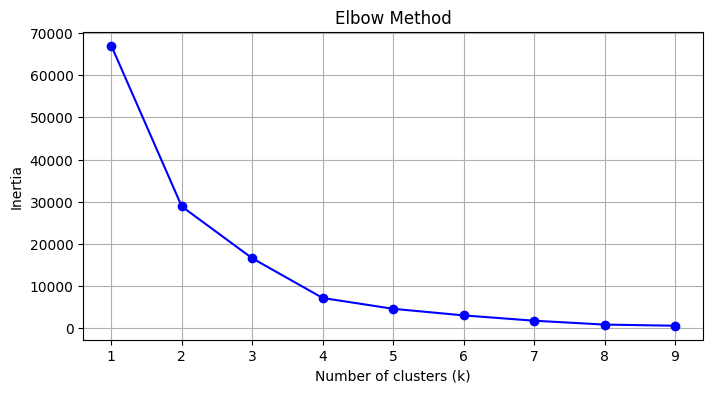

In [173]:
from sklearn.cluster import KMeans

# Use only original features (no cluster label column)
grains_features = grains_df[['sugar', 'cal', 'protein', 'fat', 'sodium']]

# Elbow Method (manual – compatible with scikit-learn 1.8+)
inertias = []
k_range = range(1, 10)
for k_val in k_range:
    km = KMeans(n_clusters=k_val, random_state=306, n_init=10)
    km.fit(grains_features)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

## Implementing K-Means Clustering

In [174]:
# Define the number of clusters
k = 4

# Apply K-Means on original features only
grains_features = grains_df[['sugar', 'cal', 'protein', 'fat', 'sodium']]
kmeans_model = KMeans(n_clusters=k, random_state=306)
kmeans_model.fit(grains_features)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",306
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [175]:
kmeans_model.cluster_centers_

array([[  8.875, 110.   ,   1.875,   1.625, 201.25 ],
       [  6.75 ,  85.   ,   3.25 ,   0.75 , 133.75 ],
       [  3.   ,  90.   ,   5.   ,   1.5  , 275.   ],
       [  8.   , 120.   ,   3.   ,   5.   ,  15.   ]])

In [176]:
kmeans_model.labels_

array([1, 3, 2, 1, 0, 0, 1, 0, 0, 0, 0, 2, 0, 1, 0], dtype=int32)

In [177]:
from inspect import getframeinfo
# Add the cluster labels to the original data
grains_df['kmeans_clusters'] = kmeans_model.labels_
# Display the origfinal data with cluster labels
grains_df

,sugar,cal,protein,fat,sodium,kmeans_clusters
0,6,70,4,1,130,1
1,8,120,3,5,15,3
2,5,70,4,1,260,2
3,0,50,4,0,140,1
4,8,110,2,2,200,0
5,10,110,2,2,180,0
6,14,110,2,0,125,1
7,8,130,3,2,210,0
8,6,90,2,1,200,0
9,5,90,3,0,210,0


In [178]:
# Re-fit on original features only
k = 4
grains_features = grains_df[['sugar', 'cal', 'protein', 'fat', 'sodium']]
kmeans_model = KMeans(n_clusters=k, random_state=306)
kmeans_model.fit(grains_features)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",306
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [179]:
# Centroid of Clusters

grains_df.groupby('kmeans_clusters').mean()

,sugar,cal,protein,fat,sodium
kmeans_clusters,,,,,
0,8.875,110.0,1.875,1.625,201.25
1,6.750,85.0,3.250,0.750,133.75
2,3.000,90.0,5.000,1.500,275.00
3,8.000,120.0,3.000,5.000,15.00


In [180]:
kmeans_model.inertia_

7184.625

#Comparing Clustering Performance
The Silhouette Score is a measure of how similar an object is to its own cluster compared to other clusters. It ranges from -1 to * 1, where a higher score indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters. Here’s a general interpretation of the Silhouette Score:

* +1: Points are very well clustered.
* 0: Points are on or very close to the decision boundary between two clusters.
* -1: Points are misclassified and should be assigned to another cluster.

Based on the Silhouette Scores, K-Means clustering is marginally better for this specific dataset. However, the low scores suggest that there might be an underlying issue with the clustering process, such as:

* The number of clusters (K) may not be optimal.
* The features used for clustering might not be the best choice.
* The data may not have distinct clusters.

In [181]:
from sklearn.metrics import silhouette_score
# Silhouette Score for K-Means
ori_features = grains_df.iloc[:, :-1]
kmeans_score1 = silhouette_score(ori_features, grains_df['kmeans_clusters'])
print(f'Silhouette Score for K-Means original data: {kmeans_score1:.2f}')

Silhouette Score for K-Means original data: 0.50


In [182]:
#Silhouette analysis
from sklearn.metrics import silhouette_score

ss = []

for i in range(2, 7):
    km = KMeans(n_clusters=i, random_state=306)
    km.fit(ori_features)
    sil_avg = round(silhouette_score(ori_features, km.labels_), 4)
    ss.append([sil_avg, i])
ss

[[0.4973, 2], [0.4655, 3], [0.4972, 4], [0.5173, 5], [0.422, 6]]

# Refining Clustering Analysis

In [183]:
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
grains_scaled = scaler.fit_transform(grains_features)

# หา k ที่ดีที่สุดหลัง scaling ด้วย Silhouette Score
ss_scaled = []
for i in range(2, 7):
    km = KMeans(n_clusters=i, random_state=306, n_init=10)
    km.fit(grains_scaled)
    sil = round(float(silhouette_score(grains_scaled, km.labels_)), 4)
    ss_scaled.append([sil, i])

print("Silhouette Scores (scaled):")
for sil, k_val in sorted(ss_scaled, reverse=True):
    print(f"  k={k_val}: {sil}")

best_k_scaled = max(ss_scaled, key=lambda x: x[0])[1]
print(f"\nBest k after scaling: {best_k_scaled}")

# Fit best model
km_refined = KMeans(n_clusters=best_k_scaled, random_state=306, n_init=10)
km_refined.fit(grains_scaled)
grains_df['refined_clusters'] = km_refined.labels_

print("\nCluster summary (scaled):")
print(grains_df.groupby('refined_clusters')[['sugar','cal','protein','fat','sodium']].mean().round(2))

Silhouette Scores (scaled):
  k=3: 0.3357
  k=2: 0.3288
  k=4: 0.3244
  k=5: 0.2611
  k=6: 0.2165

Best k after scaling: 3

Cluster summary (scaled):
                  sugar    cal  protein   fat  sodium
refined_clusters                                     
0                 10.12  115.0     1.88  1.75  183.12
1                  3.83   80.0     3.83  0.83  205.00
2                  8.00  120.0     3.00  5.00   15.00


# การบ้าน - ปรับช่วงข้อมูลด้วย StandardScaler หรือ MinMaxScaler ดีไหม?

                       best_k  silhouette
Original (No Scaling)     5.0      0.5173
StandardScaler            3.0      0.3357
MinMaxScaler              3.0      0.3463


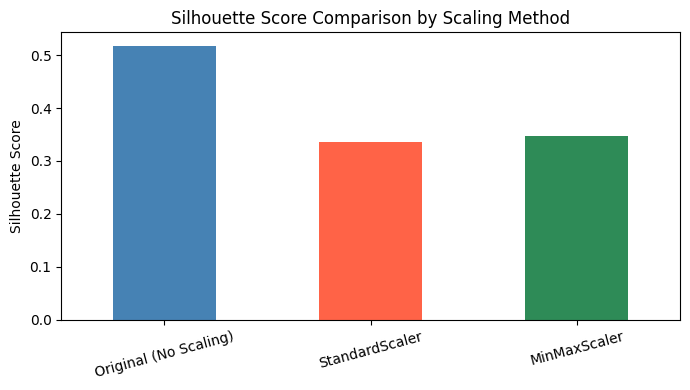


Best method: Original (No Scaling) (Silhouette = 0.5173)


In [184]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

results = {}

for scaler_name, scaler in [('Original (No Scaling)', None),
                              ('StandardScaler', StandardScaler()),
                              ('MinMaxScaler', MinMaxScaler())]:
    X = grains_features.values if scaler is None else scaler.fit_transform(grains_features)
    best_sil, best_k = -1, 2
    for k_val in range(2, 7):
        km = KMeans(n_clusters=k_val, random_state=306, n_init=10)
        km.fit(X)
        sil = float(silhouette_score(X, km.labels_))
        if sil > best_sil:
            best_sil, best_k = sil, k_val
    results[scaler_name] = {'best_k': best_k, 'silhouette': round(best_sil, 4)}

results_df = pd.DataFrame(results).T
print(results_df.to_string())

# Bar chart comparison
results_df['silhouette'].plot(kind='bar', figsize=(7, 4), color=['steelblue','tomato','seagreen'],
                               title='Silhouette Score Comparison by Scaling Method')
plt.ylabel('Silhouette Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best_method = results_df['silhouette'].idxmax()
print(f"\nBest method: {best_method} (Silhouette = {results_df.loc[best_method,'silhouette']})")